# RNN and GRU Language Modeling

Character-level sequence modeling with recurrent neural networks, including training with gradient clipping, text generation, sequence-length experiments, gradient analysis, and a GRU extension.

> Portfolio-ready copy of the original completed experiment. Experimental code and saved outputs are preserved; assignment-administration text has been removed.

## Learning Objectives
1. Understand RNN architecture and computation
2. Implement character-level language model from scratch
3. Analyze vanishing/exploding gradient problems
4. Generate text using trained RNN
5. Compare RNN performance with n-gram baselines

**TOTAL POINTS:** 100  
**ESTIMATED TIME:** 4-6 hours

---


## Setup and Imports


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.8.0+cu126
Device: cuda


---
## PART 1: Data Preparation

In this section, you will:
- Load and preprocess text data
- Build character-level vocabulary
- Create training sequences


In [ ]:
import re, string
from pathlib import Path

def load_text_data(file_path=None):
    """
    Load text data for language modeling.

    TODO (3 points):
    - Load the text file
    - Clean the text (lowercase, handle special characters)
    - Return the processed text
    """
    if file_path is not None and Path(file_path).exists():
        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
    else:
        # Sample text if no file provided
        text = (
            """To be, or not to be, that is the question:
            Whether 'tis nobler in the mind to suffer
            The slings and arrows of outrageous fortune,
            Or to take arms against a sea of troubles
            And by opposing end them. To die—to sleep,
            No more; and by a sleep to say we end
            The heart-ache and the thousand natural shocks
            That flesh is heir to: 'tis a consummation
            Devoutly to be wish'd."""
            * 50
        )  # Repeat for more data

    # Text preprocessing
    processed_text = text.lower()
    processed_text = re.sub(r"\s+", " ", processed_text).strip()
    allowed = set(string.ascii_lowercase + string.digits + " .,;:'\"!?()-\n")
    processed_text = "".join(ch if ch in allowed else " " for ch in processed_text)
    processed_text = re.sub(r" {2,}", " ", processed_text)

    return processed_text

In [ ]:
def create_vocabulary(text):
    """
    Create character-level vocabulary.

    TODO (4 points):
    - Create char to index mapping
    - Create index to char mapping
    - Return both dictionaries and vocabulary size
    """
    # Convert text into sorted unique set of characters
    chars = sorted(list(set(text)))

    # Character to index and index to character mappings
    char2idx = {c: i for i, c in enumerate(chars)}
    idx2char = {i: c for i, c in enumerate(chars)}

    # Vocabulary size
    vocab_size = len(chars)

    return char2idx, idx2char, vocab_size

In [ ]:
import numpy as np

def text_to_sequences(text, char2idx, seq_length=50):
    """
    Convert text to sequences of indices for training.

    TODO (3 points):
    - Create input sequences of length seq_length
    - Create target sequences (shifted by 1)
    - Return as numpy arrays
    """
    X = []
    y = []

    # Create input and target sequences
    for i in range(0, len(text) - seq_length):
        seq_in = text[i : i + seq_length]
        seq_out = text[i + seq_length]
        X.append([char2idx[c] for c in seq_in])
        y.append(char2idx[seq_out])

    # Convert to numpy arrays
    X = np.array(X)
    y = np.array(y)

    return X, y

In [ ]:
# Test Part 1
text = load_text_data()
char2idx, idx2char, vocab_size = create_vocabulary(text)
X_train, y_train = text_to_sequences(text, char2idx, seq_length=50)

print(f"Vocabulary size: {vocab_size}")
print(f"Number of training sequences: {len(X_train)}")
print(f"Sample characters: {list(char2idx.keys())[:20]}")

Vocabulary size: 30
Number of training sequences: 18200
Sample characters: [' ', "'", ',', '-', '.', ':', ';', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n']


---
## PART 2: Vanilla RNN Implementation

Implement a vanilla RNN following the equations:
- $h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b_h)$
- $y_t = W_{hy} h_t + b_y$


In [ ]:
import torch
import torch.nn as nn

class VanillaRNN(nn.Module):
    """
    Vanilla RNN for character-level language modeling.

    TODO (25 points): Implement the RNN architecture
    """

    def __init__(self, vocab_size, hidden_size, num_layers=1):
        """
        TODO (5 points): Initialize the RNN layers
        """
        super(VanillaRNN, self).__init__()

        # Define layers
        # Embedding layer converts character indices into dense vectors
        self.embedding = nn.Embedding(vocab_size, hidden_size)

        # RNN layer: tanh-based recurrent layer
        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True
        )

        # Fully connected layer mapping hidden state → vocabulary logits
        self.fc = nn.Linear(hidden_size, vocab_size)

        # Store parameters
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, x, hidden=None):
        """
        TODO (10 points): Implement forward pass
        """
        # Embed input sequence [batch, seq_len] → [batch, seq_len, hidden_size]
        embedded = self.embedding(x)

        # Forward through RNN
        output, hidden = self.rnn(embedded, hidden)

        # Map hidden states to logits over vocabulary
        logits = self.fc(output)

        return logits, hidden

    def init_hidden(self, batch_size):
        """
        TODO (5 points): Initialize hidden state
        """
        # Initialize hidden state with zeros [num_layers, batch, hidden_size]
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

    def get_gradient_norms(self):
        """
        TODO (5 points): Calculate gradient norms
        """
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                param_norm = p.grad.detach().data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        return total_norm

---
## PART 3: Training Loop

Implement the training loop with gradient clipping to prevent exploding gradients.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

def train_rnn(model, X_train, y_train, epochs=50, batch_size=32,
              learning_rate=0.001, clip_grad=5.0):
    """
    TODO (20 points): Implement training loop with gradient clipping
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Define loss function (cross-entropy) and optimizer (Adam)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    losses = []
    grad_norms = []

    # Convert training data to torch tensors
    if not isinstance(X_train, torch.Tensor):
        X_train = torch.tensor(X_train, dtype=torch.long)
        y_train = torch.tensor(y_train, dtype=torch.long)

    dataset_size = len(X_train)

    # Training loop
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        total_batches = 0

        # Shuffle data indices each epoch
        indices = torch.randperm(dataset_size)

        for i in range(0, dataset_size, batch_size):
            batch_idx = indices[i:i + batch_size]
            x_batch = X_train[batch_idx].to(device)
            y_batch = y_train[batch_idx].to(device)

            # Initialize hidden state
            hidden = model.init_hidden(batch_size=x_batch.size(0)).to(device)

            # Forward pass
            outputs, hidden = model(x_batch, hidden)
            # Use the last time-step output to predict next char
            logits = outputs[:, -1, :]  # [batch, vocab_size]

            # Compute loss
            loss = criterion(logits, y_batch)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

            # Update weights
            optimizer.step()

            # Record loss
            epoch_loss += loss.item()
            total_batches += 1

        # Compute average loss per epoch
        avg_loss = epoch_loss / total_batches
        losses.append(avg_loss)

        # Record gradient norm using helper method
        grad_norm = model.get_gradient_norms()
        grad_norms.append(grad_norm)

        print(f"Epoch {epoch:03d} | Loss: {avg_loss:.4f} | Grad Norm: {grad_norm:.4f}")

    return losses, grad_norms

Epoch 001 | Loss: 0.6799 | Grad Norm: 0.1700
Epoch 002 | Loss: 0.0231 | Grad Norm: 0.0475
Epoch 003 | Loss: 0.0048 | Grad Norm: 0.0166
Epoch 004 | Loss: 0.0023 | Grad Norm: 0.0143
Epoch 005 | Loss: 0.0013 | Grad Norm: 0.0092
Epoch 006 | Loss: 0.0008 | Grad Norm: 0.0071
Epoch 007 | Loss: 0.0005 | Grad Norm: 0.0034
Epoch 008 | Loss: 0.0004 | Grad Norm: 0.0027
Epoch 009 | Loss: 0.0002 | Grad Norm: 0.0019
Epoch 010 | Loss: 0.0002 | Grad Norm: 0.0018
Epoch 011 | Loss: 0.0001 | Grad Norm: 0.0008
Epoch 012 | Loss: 0.0001 | Grad Norm: 0.0009
Epoch 013 | Loss: 0.0001 | Grad Norm: 0.0005
Epoch 014 | Loss: 0.0000 | Grad Norm: 0.0003
Epoch 015 | Loss: 0.0000 | Grad Norm: 0.0003
Epoch 016 | Loss: 0.0000 | Grad Norm: 0.0002
Epoch 017 | Loss: 0.0000 | Grad Norm: 0.0002
Epoch 018 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 019 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 020 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 021 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 022 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 023 

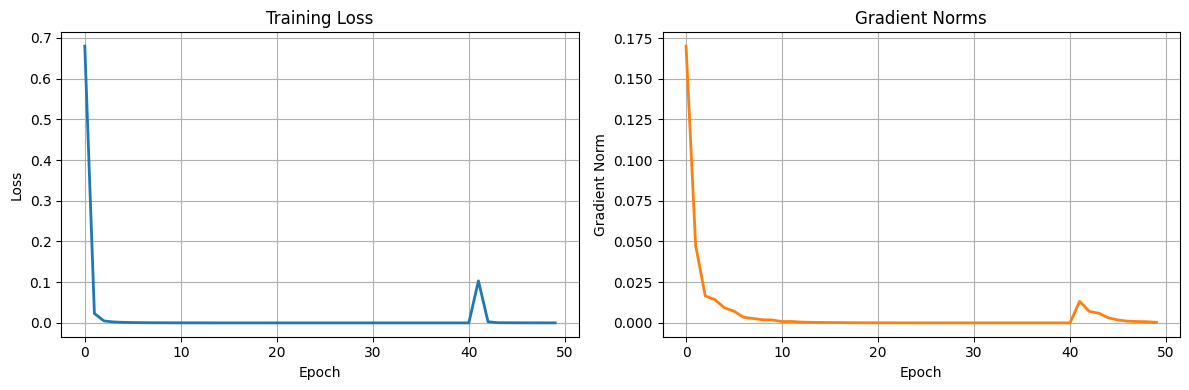

In [ ]:
# Train the model
model = VanillaRNN(vocab_size=vocab_size, hidden_size=128, num_layers=2)
losses, grad_norms = train_rnn(model, X_train, y_train, epochs=50)

# Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Training loss plot
plt.subplot(1, 2, 1)
plt.plot(losses, color='tab:blue', linewidth=2)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# Gradient norm plot
plt.subplot(1, 2, 2)
plt.plot(grad_norms, color='tab:orange', linewidth=2)
plt.title('Gradient Norms')
plt.xlabel('Epoch')
plt.ylabel('Gradient Norm')
plt.grid(True)

plt.tight_layout()
plt.show()

---
## PART 4: Text Generation

Generate text using the trained model with temperature sampling.


In [ ]:
import torch
import numpy as np

def generate_text(model, char2idx, idx2char, seed_text="T",
                  length=200, temperature=1.0):
    """
    TODO (15 points): Generate text using trained model

    Args:
        model: Trained VanillaRNN model
        char2idx: Dictionary mapping characters → indices
        idx2char: Dictionary mapping indices → characters
        seed_text: Initial text prompt to start generation
        length: Number of characters to generate
        temperature: Controls randomness in sampling
                     (low = more deterministic, high = more random)
    """
    model.eval()
    device = next(model.parameters()).device

    # Start with seed text
    generated = seed_text
    input_seq = [char2idx.get(c, 0) for c in seed_text]

    # Convert to tensor of shape [1, seq_len]
    input_tensor = torch.tensor([input_seq], dtype=torch.long).to(device)

    # Initialize hidden state
    hidden = model.init_hidden(batch_size=1).to(device)

    with torch.no_grad():
        for _ in range(length):
            # Forward pass through model
            logits, hidden = model(input_tensor, hidden)

            # Get logits of last time step
            logits = logits[:, -1, :] / max(temperature, 1e-8)

            # Convert to probabilities
            probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()

            # Sample next character index based on probabilities
            next_idx = int(np.random.choice(len(probs), p=probs))
            next_char = idx2char[next_idx]

            # Append to generated text
            generated += next_char

            # Prepare next input tensor (append new character index)
            input_tensor = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return generated

In [ ]:
# Generate text with different temperatures
for temp in [0.5, 1.0, 1.5]:
    generated = generate_text(
        model,
        char2idx,
        idx2char,
        seed_text="To be",
        length=200,
        temperature=temp
    )

    print(f"\n{'='*70}")
    print(f"Temperature: {temp}")
    print(f"{'='*70}")
    print(generated)


Temperature: 0.5
To be wish'd.to be, or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fortune, or to take arms against a sea of troubles and by opposing end 

Temperature: 1.0
To be wish'd.to be, or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fortune, or to take arms against a sea of troubles and by opposing end 

Temperature: 1.5
To be wish'd.to be, or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fout a toa toa toa toa toa s and arrows of outrageous fortune, or to ta


---
## PART 5: Analysis and Experiments

### 5.1 Gradient Analysis


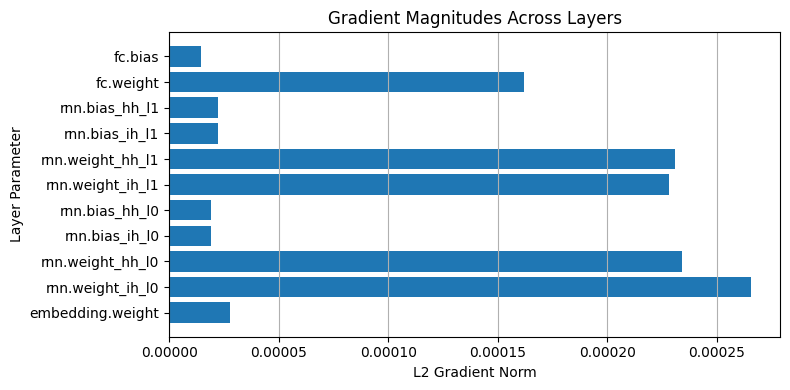

Gradient Magnitudes by Layer:
embedding.weight         : 0.000028
rnn.weight_ih_l0         : 0.000266
rnn.weight_hh_l0         : 0.000234
rnn.bias_ih_l0           : 0.000019
rnn.bias_hh_l0           : 0.000019
rnn.weight_ih_l1         : 0.000228
rnn.weight_hh_l1         : 0.000231
rnn.bias_ih_l1           : 0.000022
rnn.bias_hh_l1           : 0.000022
fc.weight                : 0.000162
fc.bias                  : 0.000015

Average Gradient Norm: 0.000113
⚠️ Gradients may be vanishing.


In [ ]:
def analyze_vanishing_gradients(model, X_sample, y_sample):
    """
    TODO (10 points): Analyze gradient flow through time
    """
    import torch
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train()

    # Convert input sample tensors if they are numpy arrays
    if not isinstance(X_sample, torch.Tensor):
        X_sample = torch.tensor(X_sample, dtype=torch.long)
    if not isinstance(y_sample, torch.Tensor):
        y_sample = torch.tensor(y_sample, dtype=torch.long)

    # Take a small batch for gradient analysis
    X_sample = X_sample.to(device)
    y_sample = y_sample.to(device)

    # Initialize hidden state
    hidden = model.init_hidden(batch_size=X_sample.size(0)).to(device)

    # Forward pass
    outputs, hidden = model(X_sample, hidden)
    logits = outputs[:, -1, :]  # use last output for next char prediction

    # Compute loss
    criterion = torch.nn.CrossEntropyLoss()
    loss = criterion(logits, y_sample)

    # Backpropagate
    model.zero_grad()
    loss.backward()

    # Collect gradient norms layer by layer (embedding, RNN, FC)
    grad_magnitudes = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_magnitudes[name] = param.grad.detach().norm(2).item()

    # Plot gradient magnitudes
    plt.figure(figsize=(8, 4))
    plt.barh(list(grad_magnitudes.keys()), list(grad_magnitudes.values()), color='tab:blue')
    plt.title("Gradient Magnitudes Across Layers")
    plt.xlabel("L2 Gradient Norm")
    plt.ylabel("Layer Parameter")
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

    # Print summary for inspection
    print("Gradient Magnitudes by Layer:")
    for name, val in grad_magnitudes.items():
        print(f"{name:25s}: {val:.6f}")

    # Optional: report gradient stability
    avg_grad = sum(grad_magnitudes.values()) / len(grad_magnitudes)
    print(f"\nAverage Gradient Norm: {avg_grad:.6f}")
    if avg_grad < 1e-3:
        print("⚠️ Gradients may be vanishing.")
    elif avg_grad > 10:
        print("⚠️ Gradients may be exploding.")
    else:
        print("✅ Gradients are stable.")


# Run analysis
analyze_vanishing_gradients(model, X_train[:10], y_train[:10])

### 5.2 Sequence Length Experiments



Training model with sequence length = 25
Epoch 001 | Loss: 0.5099 | Grad Norm: 0.3555
Epoch 002 | Loss: 0.0129 | Grad Norm: 0.0675
Epoch 003 | Loss: 0.0368 | Grad Norm: 0.0122
Epoch 004 | Loss: 0.0019 | Grad Norm: 0.0037
Epoch 005 | Loss: 0.0008 | Grad Norm: 0.0028
Epoch 006 | Loss: 0.0005 | Grad Norm: 0.0019
Epoch 007 | Loss: 0.0004 | Grad Norm: 0.0013
Epoch 008 | Loss: 0.0003 | Grad Norm: 0.0010
Epoch 009 | Loss: 0.0002 | Grad Norm: 0.0008
Epoch 010 | Loss: 0.0002 | Grad Norm: 0.0007

Training model with sequence length = 50
Epoch 001 | Loss: 0.5313 | Grad Norm: 0.1073
Epoch 002 | Loss: 0.0233 | Grad Norm: 0.0233
Epoch 003 | Loss: 0.0244 | Grad Norm: 0.0118
Epoch 004 | Loss: 0.0013 | Grad Norm: 0.0052
Epoch 005 | Loss: 0.0007 | Grad Norm: 0.0032
Epoch 006 | Loss: 0.0005 | Grad Norm: 0.0026
Epoch 007 | Loss: 0.0003 | Grad Norm: 0.0019
Epoch 008 | Loss: 0.0003 | Grad Norm: 0.0009
Epoch 009 | Loss: 0.0002 | Grad Norm: 0.0011
Epoch 010 | Loss: 0.0002 | Grad Norm: 0.0010

Training model 

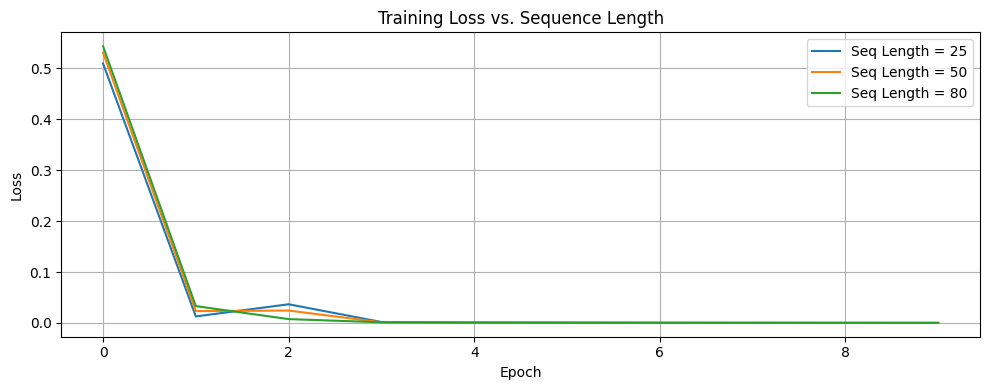


Final losses by sequence length:
  Seq Length  25: Final Loss = 0.0002
  Seq Length  50: Final Loss = 0.0002
  Seq Length  80: Final Loss = 0.0002


In [ ]:
def experiment_with_sequence_length(X_train, y_train, char2idx, vocab_size):
    """
    TODO (10 points): Experiment with different sequence lengths

    Train separate RNNs using different sequence lengths and compare
    their performance to see how context window size affects learning.
    """
    import torch
    import matplotlib.pyplot as plt

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_results = {}
    seq_lengths = [25, 50, 80]   # I can adjust if needed but this should be fine

    for seq_len in seq_lengths:
        print(f"\n{'='*70}")
        print(f"Training model with sequence length = {seq_len}")
        print(f"{'='*70}")

        # Rebuild training data with the new sequence length
        X_seq, y_seq = text_to_sequences(text, char2idx, seq_length=seq_len)

        # Initialize a new model for this sequence length
        model = VanillaRNN(vocab_size=vocab_size, hidden_size=128, num_layers=2).to(device)

        # Train the model for fewer epochs for quick comparison
        losses, grad_norms = train_rnn(model, X_seq, y_seq, epochs=10, batch_size=64, learning_rate=0.003)

        # Generate sample text from this model
        sample = generate_text(model, char2idx, idx2char, seed_text="To be", length=200, temperature=1.0)

        # Store results
        model_results[seq_len] = {
            "final_loss": losses[-1],
            "losses": losses,
            "grad_norms": grad_norms,
            "sample": sample
        }

    # Plot training losses for different sequence lengths
    plt.figure(figsize=(10, 4))
    for L, res in model_results.items():
        plt.plot(res["losses"], label=f"Seq Length = {L}")
    plt.title("Training Loss vs. Sequence Length")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print summary
    print("\nFinal losses by sequence length:")
    for L, res in model_results.items():
        print(f"  Seq Length {L:>3}: Final Loss = {res['final_loss']:.4f}")

    return model_results


# Run experiments
seq_results = experiment_with_sequence_length(X_train, y_train, char2idx, vocab_size)

### 5.3 Bigram Baseline Comparison


In [ ]:
import numpy as np
import math

def compare_with_bigram_baseline(text, char2idx, idx2char):
    """
    TODO (10 points): Implement bigram model and compare

    Build a simple bigram model P(c_t | c_{t-1}) with Laplace smoothing.
    Evaluate its average negative log-likelihood (NLL) on a held-out set,
    and generate sample text for qualitative comparison.
    """
    # Step 1: Initialize bigram count matrix
    V = len(char2idx)
    counts = np.ones((V, V), dtype=np.float64)  # Laplace smoothing (add-1)

    # Step 2: Count character transitions
    indices = [char2idx[c] for c in text]
    for a, b in zip(indices[:-1], indices[1:]):
        counts[a, b] += 1.0

    # Step 3: Convert counts to conditional probabilities
    probs = counts / counts.sum(axis=1, keepdims=True)

    # Step 4: Evaluate model performance on a held-out test split
    split = int(0.8 * len(indices))
    test_pairs = list(zip(indices[split:-1], indices[split+1:]))

    nll = 0.0
    for prev_i, next_i in test_pairs:
        p = probs[prev_i, next_i]
        nll += -math.log(p + 1e-12)
    avg_nll = nll / max(1, len(test_pairs))

    # Step 5: Generate sample text from the bigram model
    rng = np.random.default_rng(0)
    cur = indices[split]  # start from a test-set character
    generated = [idx2char[cur]]
    for _ in range(300):  # generate ~300 characters
        p = probs[cur]
        next_idx = int(rng.choice(V, p=p))
        generated.append(idx2char[next_idx])
        cur = next_idx
    sample_text = "".join(generated)

    # Step 6: Print results
    print(f"Bigram Model Average NLL (held-out): {avg_nll:.4f}")
    print("\nSample Bigram Generated Text:\n")
    print(sample_text[:500])

    # Step 7: Return results
    return {
        "avg_nll": float(avg_nll),
        "sample": sample_text
    }


# Run comparison
bigram_results = compare_with_bigram_baseline(text, char2idx, idx2char)

Bigram Model Average NLL (held-out): 1.8368

Sample Bigram Generated Text:

to a trmonsl t tatind armmivwisin: o: tr o: fes s to t f no ale qro th'traund wsaranofles trt tutay.tinouffes tl t tis t hetindin: qutindens opp is the h'thet-n indks dese,whatortrouf sle;qur on wi.tur blemms os iep isatoue atonar ther p tis wsatles thevonde tothe hee i to towsayseppcor timiealem.tou


---


#BONUS - GRU VERSION


In [ ]:
import torch
import torch.nn as nn

class GRULanguageModel(nn.Module):
    """
    Bonus (Up to 10 points):
    GRU-based character-level language model.
    i will Drop-in replacement for VanillaRNN with the same interface.
    """

    def __init__(self, vocab_size, hidden_size=128, num_layers=2):
        super(GRULanguageModel, self).__init__()

        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, hidden_size)

        # GRU instead of vanilla RNN
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, vocab_size)

        # Save hyperparameters
        self.hidden_size = hidden_size
        self.num_layers = num_layers

    def forward(self, x, hidden=None):
        emb = self.embedding(x)           # [B, T, H]
        out, hidden = self.gru(emb, hidden)
        logits = self.fc(out)             # [B, T, V]
        return logits, hidden

    def init_hidden(self, batch_size):
        # Initialize hidden state with zeros [num_layers, batch, hidden_size]
        return torch.zeros(self.num_layers, batch_size, self.hidden_size)

    def get_gradient_norms(self):
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                total_norm += p.grad.detach().data.norm(2).item() ** 2
        return total_norm ** 0.5

In [ ]:
# Train GRU model (for the bonus version)
model_gru = GRULanguageModel(vocab_size=vocab_size, hidden_size=128, num_layers=2)
losses_gru, grad_norms_gru = train_rnn(model_gru, X_train, y_train, epochs=30, batch_size=64, learning_rate=0.003)

# Comparing my results
print(f"Final GRU training loss: {losses_gru[-1]:.4f}")

Epoch 001 | Loss: 0.5623 | Grad Norm: 0.0361
Epoch 002 | Loss: 0.0052 | Grad Norm: 0.0101
Epoch 003 | Loss: 0.0017 | Grad Norm: 0.0045
Epoch 004 | Loss: 0.0009 | Grad Norm: 0.0023
Epoch 005 | Loss: 0.0006 | Grad Norm: 0.0016
Epoch 006 | Loss: 0.0004 | Grad Norm: 0.0015
Epoch 007 | Loss: 0.0003 | Grad Norm: 0.0010
Epoch 008 | Loss: 0.0002 | Grad Norm: 0.0007
Epoch 009 | Loss: 0.0002 | Grad Norm: 0.0006
Epoch 010 | Loss: 0.0001 | Grad Norm: 0.0005
Epoch 011 | Loss: 0.0001 | Grad Norm: 0.0004
Epoch 012 | Loss: 0.0001 | Grad Norm: 0.0003
Epoch 013 | Loss: 0.0001 | Grad Norm: 0.0002
Epoch 014 | Loss: 0.0001 | Grad Norm: 0.0003
Epoch 015 | Loss: 0.0000 | Grad Norm: 0.0002
Epoch 016 | Loss: 0.0000 | Grad Norm: 0.0002
Epoch 017 | Loss: 0.0000 | Grad Norm: 0.0002
Epoch 018 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 019 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 020 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 021 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 022 | Loss: 0.0000 | Grad Norm: 0.0001
Epoch 023 

In [ ]:
#Let me generate text:
generated_gru = generate_text(model_gru, char2idx, idx2char, seed_text="To be", length=200, temperature=0.8)
print("\nGRU Generated Text:\n", generated_gru)


GRU Generated Text:
 To be, or not to be, that is the question: whether 'tis nobler in the mind to suffer the slings and arrows of outrageous fortune, or to take arms against a sea of troubles and by opposing end them. to die 
